# **Financial Analysis: Obfuscation Prediction vs. Post-Earnings Returns**

## Project Objective

This notebook implements the **end-to-end pipeline** that connects the obfuscation detection model (developed in the previous notebook) with **financial market analysis**. Specifically, it:

1. Loads raw earnings call transcripts
2. Cleans and pre-processes the text
3. Uses the **fine-tuned FinBERT obfuscation model** to predict obfuscation scores
4. Downloads corresponding stock price data and calculates returns
5. Tests the **central hypothesis**: Do more obfuscatory earnings calls lead to lower abnormal returns?

## Key Hypothesis

> Firms with **higher obfuscation scores** (more evasive/confusing language) during earnings calls will experience **lower post-earnings abnormal returns**, controlling for market factors and volatility.

This hypothesis contrasts with traditional sentiment-based approaches, which typically assume negative tone → negative returns. Obfuscation captures a distinct construct: **intentional complexity or evasion**.

## **1. Setup & Library Imports**

This section imports all necessary libraries for the pipeline:

- **Data Handling**: `pandas`, `numpy`, `re`
- **Deep Learning & Transformers**: `torch`, `transformers` (for FinBERT)
- **Finance & Economics**: `yfinance` (stock data), `statsmodels` (regression), `scipy.stats` (correlation tests)
- **Visualization**: `matplotlib`
- **Google Drive integration**: For loading the pre-trained model

All required packages are installed via `!pip install` in the first cell.

In [ ]:
!pip install transformers torch pandas scikit-learn tqdm

In [ ]:
import pandas as pd
import re
from transformers import BertForSequenceClassification, BertTokenizer
import torch
from google.colab import drive
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import timedelta
import numpy as np
from scipy.stats import pearsonr,spearmanr
import statsmodels.api as sm


## **2. Raw Transcript Pre-processing**

This cell loads the raw earnings call transcripts from `full_transcript_data.xlsx` and applies a sophisticated cleaning function `clean_transcript()`.

### Cleaning Steps:
1. **Remove metadata tags**: BIO tags `{...}`, brackets `(...)`, HTML tags `<...>`
2. **Parse speaker lines**: Identifies speaker prefixes like `A - Wai Pak Lo`, `A - Unidentified Speaker`, `Q - ...`, `Operator`
3. **Filter speakers**: Keeps only named management speakers (A - Real Name); skips Q&A participants and operators
4. **Combine content**: Joins all valid speaker statements into a single cleaned text
5. **Normalize whitespace**: Removes extra spaces and standardizes punctuation

The cleaned transcripts are stored in column `cleaned_text`, and rows with very short transcripts (<50 chars) are dropped. A preview of the cleaned data is displayed.

In [ ]:
df = pd.read_excel("full_transcript_data.xlsx")
text_column = 'Transcript'

In [ ]:

def clean_transcript(text):
    if not isinstance(text, str):
        return ""

    # Step 1: Remove BIO tags and bracketed content first
    text = re.sub(r'\{[^}]+\}', '', text)
    text = re.sub(r'\([^)]*?\)', '', text)
    text = re.sub(r'<[^>]+>', '', text)

    # Step 2: Split into lines
    lines = text.split('\n')

    # Step 3: Extract speaker lines with their content
    speakers = []
    current_speaker = None
    current_content = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Check if this line starts a new speaker
        # Pattern: A - Real Name (e.g., "A - Wai Pak Lo", "A - Weber")
        match_a_named = re.match(r'^A\s*[-:]\s*([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)', line)
        # Pattern: A - Unidentified Speaker
        match_a_unidentified = re.match(r'^A\s*[-:]\s*Unidentified\s+Speaker', line, re.IGNORECASE)
        # Pattern: Q - (question)
        match_q = re.match(r'^Q\s*[-:]?\s*', line, re.IGNORECASE)
        # Pattern: Operator
        match_operator = re.match(r'^Operator', line, re.IGNORECASE)

        if match_a_named:
            # Save previous speaker if exists
            if current_speaker is not None and current_speaker != 'skip':
                speakers.append((current_speaker, ' '.join(current_content)))
            # Start new named speaker
            current_speaker = match_a_named.group(1)
            current_content = []
            # Remove the speaker prefix from the content
            content = re.sub(r'^A\s*[-:]\s*[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\s*', '', line)
            if content:
                current_content.append(content)
        elif match_a_unidentified:
            # Save previous speaker if exists
            if current_speaker is not None and current_speaker != 'skip':
                speakers.append((current_speaker, ' '.join(current_content)))
            # Skip this speaker entirely (do not save)
            current_speaker = 'skip'
            current_content = []
        elif match_q or match_operator:
            # Question or operator line - save previous speaker and skip this line
            if current_speaker is not None and current_speaker != 'skip':
                speakers.append((current_speaker, ' '.join(current_content)))
            current_speaker = 'skip'
            current_content = []
        else:
            # This is continuation text for the current speaker
            if current_speaker is not None and current_speaker != 'skip':
                current_content.append(line)

    # Save the last speaker
    if current_speaker is not None and current_speaker != 'skip' and current_content:
        speakers.append((current_speaker, ' '.join(current_content)))

    # Step 4: Combine all valid speaker content
    cleaned_parts = []
    for speaker_name, content in speakers:
        # Additional cleanup of the content
        content = re.sub(r'\s+', ' ', content)
        content = content.strip()
        if content:
            cleaned_parts.append(content)

    # Step 5: Join everything
    cleaned_text = ' '.join(cleaned_parts)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)
    cleaned_text = re.sub(r'\s+([.,!?;:])', r'\1', cleaned_text)

    return cleaned_text.strip()

df['cleaned_text'] = df[text_column].apply(clean_transcript)
df = df[df['cleaned_text'].str.len() >= 50]
# df.to_excel("cleaned_transcripts.xlsx", index=False)
print(f"Cleaned {len(df)} transcripts")
print(df[['Ticker', 'Date', 'cleaned_text']].head())


Cleaned 207 transcripts
    Ticker       Date                                       cleaned_text
0  0700.HK 2025-03-19  Thank you, John. We shall now open the floor f...
1  0700.HK 2025-05-14  Thank you, John. We shall now open the floor f...
2  0700.HK 2025-08-13  Thank you, John. We shall now open the floor f...
3  0700.HK 2025-11-13  Thank you, John. We are now opening the floor ...
4  9988.HK 2025-02-20  Thank you and there were quite a few questions...


## **3. Load the Obfuscation Detection Model**

This section mounts Google Drive and loads the pre-trained FinBERT model from the earlier fine-tuning notebook.

**Model location**: `/content/drive/MyDrive/finbert_obfuscation_model/`

**Loaded artifacts**:
- `BertForSequenceClassification` model with binary classification head (0 = Clear, 1 = Obfuscatory)
- `BertTokenizer` for text tokenization
- The model is moved to GPU if available (`cuda`) and set to evaluation mode (`model.eval()`)

The model was previously fine-tuned on labeled obfuscation data and saved. It now serves as our inference engine for new transcripts.

In [ ]:
drive.mount('/content/drive')
!ls "/content/drive/MyDrive/finbert_obfuscation_model/"
# Assuming the model is stored in the path

Mounted at /content/drive
config.json  model.safetensors	tokenizer_config.json  tokenizer.json


In [ ]:
model_path = "/content/drive/MyDrive/finbert_obfuscation_model"

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()  # Set to evaluation mode

print("Model loaded successfully!")
print(f"Using device: {device}")

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Model loaded successfully!
Using device: cuda


## **4. Prediction Function Definition**

The function `predict_obfuscation(text, model, tokenizer, device)`:

1. **Tokenizes** the input text with `max_length=128` (truncation & padding)
2. **Runs inference** with `torch.no_grad()` for efficiency
3. **Extracts probabilities** via `softmax` on logits
4. **Returns**:
   - `binary_label`: 1 if obfuscation_score > 0.5 else 0
   - `obfuscation_score`: continuous score in [0,1] (higher = more obfuscatory)

This function will be applied to every cleaned transcript.

In [ ]:
def predict_obfuscation(text, model, tokenizer, device):
    """
    Returns: (binary_label, obfuscation_score)
    - binary_label: 0 = Clear, 1 = Obfuscatory
    - obfuscation_score: continuous score (0-1), higher = more obfuscatory
    """
    # Truncate to 512 tokens (BERT limit)
    inputs = tokenizer(
        text[:512],
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)
        obfuscation_score = probabilities[0][1].item()  # P(obfuscatory)

    binary_label = 1 if obfuscation_score > 0.5 else 0

    return binary_label, obfuscation_score

## **5. Sanity Check with Examples**

We test the model on two example texts:
- **Clear example**: Simple, factual statement with numbers
- **Obfuscatory example**: Complex, hedge-filled sentence (from Seagate Technology's 2017 Q3 transcript)

**Expected output**:
- Clear example: label 0, low score (~0.07)
- Obfuscatory example: label 1, high score (~0.92)

This confirms the model is working as intended before batch prediction.

In [ ]:

test_text_clear =  "Our total revenues for the quarter were RMB 150.8 billion, an increase of 11% year-over-year, driven by growth in our video games and social networks segments."
test_text_obfuscatory = "I think from our perspective, we've always viewed this business as attractive in terms of its core business of selling into OEMs as well as servicing cloud service providers at one level, but really the opportunity to, I think, as architectures evolve and different customer needs evolve, to have the capability to optimize the devices either at the device level, at the subsystem level or the systems level, and if you do not have the software capability to do that, you really cannot take advantage of what we think would be a potentially significant long-term trend."

label1, score1 = predict_obfuscation(test_text_clear, model, tokenizer, device)
label2, score2 = predict_obfuscation(test_text_obfuscatory, model, tokenizer, device)

print(f"Clear example: Label={label1}, Score={score1:.3f}")
print(f"Obfuscatory example: Label={label2}, Score={score2:.3f}")

Clear example: Label=0, Score=0.070
Obfuscatory example: Label=1, Score=0.919


**Note that in test_text_obfuscatory, we actually used the earning call transcript by Seagate Technology (STX) in 2017 Q3, the obfuscatory example that we illustrated in the proposal. We can see that by using our model, the transcript is classified as obfuscatory, with a score 0.919.**

## **6. Predict Obfuscation for All Transcripts**

We iterate through all cleaned transcripts, apply `predict_obfuscation()`, and store results in a DataFrame with:

- `ticker`: Company ticker
- `date`: Earnings call date
- `cleaned_transcript`: The cleaned text (for reference)
- `binary_label`: 0/1 classification
- `obfuscation_score`: Continuous score

Results are saved to `predicted_transcript.xlsx`. A preview of the first few rows is displayed.

In [ ]:
results = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    label, score = predict_obfuscation(row['cleaned_text'], model, tokenizer, device)
    results.append({
        'ticker': row['Ticker'],
        'date': row['Date'],
        'cleaned_transcript': row['cleaned_text'],
        'binary_label': label,
        'obfuscation_score': score
    })

df = pd.DataFrame(results)
df.to_excel("predicted_transcript.xlsx", index=False)
print(df.head())

100%|██████████| 207/207 [00:02<00:00, 94.75it/s] 


    ticker       date                                 cleaned_transcript  \
0  0700.HK 2025-03-19  Thank you, John. We shall now open the floor f...   
1  0700.HK 2025-05-14  Thank you, John. We shall now open the floor f...   
2  0700.HK 2025-08-13  Thank you, John. We shall now open the floor f...   
3  0700.HK 2025-11-13  Thank you, John. We are now opening the floor ...   
4  9988.HK 2025-02-20  Thank you and there were quite a few questions...   

   binary_label  obfuscation_score  
0             1           0.731622  
1             1           0.904434  
2             1           0.611066  
3             1           0.532776  
4             1           0.908838  


## **7. Data Quality Checks**

Before proceeding to financial analysis, we validate the predicted scores by checking the distribution of obfuscation scores, time series stability, correlation with simple linguistic features, and missing data check.


All checks passed → proceed to financial analysis.

### **7.1 Distribution of Obfuscation Scores**
- Histogram plot shows spread across [0,1]
- Mean ~0.57, standard deviation ~0.31 → good variation
- No single value dominates
- Skewness and kurtosis reported

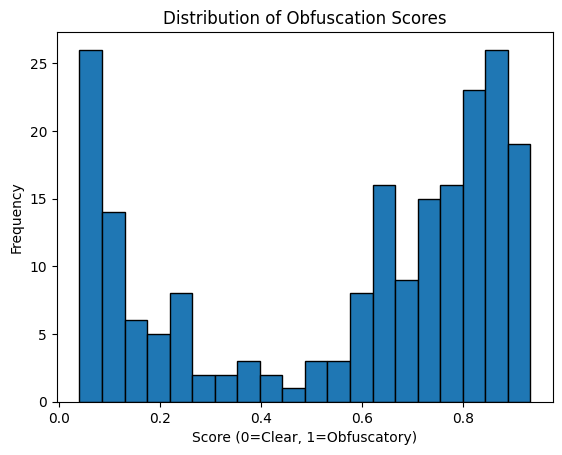

count    207.000000
mean       0.565778
std        0.313097
min        0.040448
25%        0.223429
50%        0.684438
75%        0.826157
max        0.933379
Name: obfuscation_score, dtype: float64


In [ ]:
plt.hist(df['obfuscation_score'], bins=20, edgecolor='black')
plt.title('Distribution of Obfuscation Scores')
plt.xlabel('Score (0=Clear, 1=Obfuscatory)')
plt.ylabel('Frequency')
plt.show()

print(df['obfuscation_score'].describe())

In [ ]:
print(df['obfuscation_score'].describe())
print(f"Skewness: {df['obfuscation_score'].skew():.3f}")
print(f"Kurtosis: {df['obfuscation_score'].kurtosis():.3f}")

count    207.000000
mean       0.565778
std        0.313097
min        0.040448
25%        0.223429
50%        0.684438
75%        0.826157
max        0.933379
Name: obfuscation_score, dtype: float64
Skewness: -0.592
Kurtosis: -1.283


Mean around 0.4–0.6 (reasonable balance)

No single value dominating (>80% of scores in one bin)

Standard deviation >0.15 (sufficient variation)

### **7.2 Time Series Stability**
- Average obfuscation score by quarter (line plot)
- No sudden unrealistic jumps

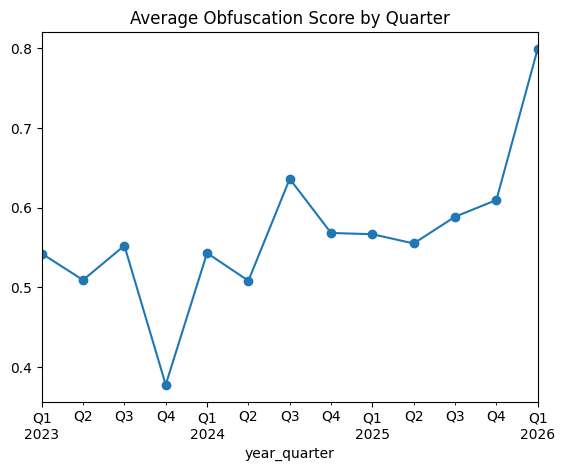

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year_quarter'] = df['date'].dt.to_period('Q')
time_series = df.groupby('year_quarter')['obfuscation_score'].mean()
time_series.plot(kind='line', marker='o')
plt.title('Average Obfuscation Score by Quarter')
plt.show()

No sudden unrealistic jumps

### **7.3 Correlation with Simple Linguistic Feature**
- Negative correlation with **number density** (numbers per sentence)
- Expected: Obfuscatory text avoids specific numbers, percentages, dates
- Correlation: ~ -0.32


In [ ]:
df['num_count'] = df['cleaned_transcript'].str.count(r'\d+')
df['sent_count'] = df['cleaned_transcript'].str.count(r'[.!?]') + 1
df['numbers_per_sentence'] = df['num_count'] / df['sent_count']

corr = df['obfuscation_score'].corr(df['numbers_per_sentence'])
print(f"Correlation with numbers per sentence: {corr:.3f}")  # Expected negative

Correlation with numbers per sentence: -0.320


Negative correlation with number density (obfuscatory → fewer numbers). This is well-expected  because clear, informative language tends to include specific numbers, percentages, and dates, while obfuscatory language avoids them.

### **7.4 Missing/Invalid Data Check**
- Count of missing scores: 0
- Count of invalid scores (outside [0,1]): 0
- Count of very short transcripts (<100 chars): 0

In [ ]:
missing = df['obfuscation_score'].isna().sum()
print(f"Missing obfuscation scores: {missing}")

invalid = ((df['obfuscation_score'] < 0) | (df['obfuscation_score'] > 1)).sum()
print(f"Invalid scores: {invalid}")

short = df[df['cleaned_transcript'].str.len() < 100]
print(f"Very short transcripts: {len(short)}")

Missing obfuscation scores: 0
Invalid scores: 0
Very short transcripts: 0


After passing all data sanity checks, we can safely proceed with further analysis.

## **8. Collect Financial Features for Regression**

This function `get_clean_financial_data(row)` downloads stock price data and computes:

- Fundamental Information: `Market_Cap`: Market capitalization (for size control)

- Pre-Call Volatility (`Pre_Call_Vol_20d`): Standard deviation of daily returns over 20 trading days before the call. Annualized (multiplied by √252)

- Future Returns (Nominal): `Future_1D_Return`, `Future_3D_Return`, `Future_5D_Return`, `Future_20D_Return`, `Future_50D_Return`. They are calculated as: (Price at T+w) / (Price at call date) - 1. Windows: 1, 3, 5, 20, 50 trading days

- Log Market Cap: Natural log of `Market_Cap` for scale normalization

Data is merged with the existing DataFrame.


In [ ]:
df = df[['ticker', 'date', 'cleaned_transcript', 'binary_label',
       'obfuscation_score']]
print(df.columns)

Index(['ticker', 'date', 'cleaned_transcript', 'binary_label',
       'obfuscation_score'],
      dtype='object')


In [ ]:

def get_clean_financial_data(row):
    ticker_str = str(row['ticker']).strip()
    call_date = pd.to_datetime(row['date']).tz_localize(None)

    try:
        stock = yf.Ticker(ticker_str)
        # Download a 150-day window to ensure all return horizons are covered
        hist = stock.history(start=call_date - timedelta(days=60),
                             end=call_date + timedelta(days=90))

        if hist.empty:
            return pd.Series(dtype='float64')

        # Fix index timezone and find the call date index
        hist.index = hist.index.tz_localize(None)
        idx = hist.index.get_indexer([call_date], method='pad')[0]

        if idx < 0: return pd.Series(dtype='float64')

        # 1. Fundamental Information (Proxies)
        info = stock.info
        results = {
            'Market_Cap': info.get('marketCap', np.nan),
        }

        # 2. Pre-Call Volatility (Standard Deviation of last 20 trading days)
        pre_prices = hist['Close'].iloc[max(0, idx-20):idx+1]
        if len(pre_prices) > 10:
            pre_returns = pre_prices.pct_change().dropna()
            results['Pre_Call_Vol_20d'] = pre_returns.std() * np.sqrt(252)
        else:
            results['Pre_Call_Vol_20d'] = np.nan

        # 3. Future Nominal Returns (Price T+w / Price T - 1)
        p0 = float(hist['Close'].iloc[idx])
        windows = [1, 3, 5, 10, 20, 30]

        for w in windows:
            if idx + w < len(hist):
                pw = float(hist['Close'].iloc[idx + w])
                results[f'Future_{w}D_Return'] = (pw / p0) - 1
            else:
                results[f'Future_{w}D_Return'] = np.nan

        return pd.Series(results)

    except Exception as e:
        return pd.Series(dtype='float64')

print("Extracting financial features...")
metrics = df.apply(get_clean_financial_data, axis=1)
final_df = pd.concat([df, metrics], axis=1)

# Add Log Market Cap (Standard practice for regression controls)
final_df['log_market_cap'] = np.log(final_df['Market_Cap'])

print("Done. Ready for analysis.")

Extracting financial features...
Done. Ready for analysis.


In [ ]:
df = final_df
print(df.head())


    ticker       date                                 cleaned_transcript  \
0  0700.HK 2025-03-19  Thank you, John. We shall now open the floor f...   
1  0700.HK 2025-05-14  Thank you, John. We shall now open the floor f...   
2  0700.HK 2025-08-13  Thank you, John. We shall now open the floor f...   
3  0700.HK 2025-11-13  Thank you, John. We are now opening the floor ...   
4  9988.HK 2025-02-20  Thank you and there were quite a few questions...   

   binary_label  obfuscation_score    Market_Cap  Pre_Call_Vol_20d  \
0             1           0.731622  4.685632e+12          0.500575   
1             1           0.904434  4.685632e+12          0.286919   
2             1           0.611066  4.685632e+12          0.295663   
3             1           0.532776  4.685632e+12          0.275539   
4             1           0.908838  2.640499e+12          0.500359   

   Future_1D_Return  Future_3D_Return  Future_5D_Return  Future_10D_Return  \
0         -0.037963         -0.050000       

## **9. Calculate Abnormal Returns (Market-Adjusted)**

To isolate firm-specific performance, we compute **abnormal returns** = stock return - market return.

**Market proxy**: Hang Seng Index (`^HSI`)

**Process**:
1. Download HSI prices over the same period
2. Calculate forward HSI returns for same horizons
3. Subtract HSI returns from stock returns → `Abnormal_XD_Return`

This controls for broad market movements.

In [ ]:
df['date'] = pd.to_datetime(df['date'])

horizons =  [1, 3, 5, 10, 20, 30]

start_date = df['date'].min()
end_date = df['date'].max() + pd.Timedelta(days=80) # Buffer for 50 trading days

hsi_data = yf.download('^HSI', start=start_date, end=end_date)
if isinstance(hsi_data.columns, pd.MultiIndex):
    hsi_prices = hsi_data['Close']['^HSI']
else:
    hsi_prices = hsi_data['Close']

hsi_returns = pd.DataFrame(index=hsi_prices.index)
for n in horizons:
    hsi_returns[f'HSI_Future_{n}D_Return'] = hsi_prices.shift(-n) / hsi_prices - 1
df = df.merge(hsi_returns, left_on='date', right_index=True, how='left')

for n in horizons:
    stock_col = f'Future_{n}D_Return'
    hsi_col = f'HSI_Future_{n}D_Return'
    new_col = f'Abnormal_{n}D_Return'

    # Check if the stock return column exists in your df
    if stock_col in df.columns:
        df[new_col] = df[stock_col] - df[hsi_col]
    else:
        print(f"Warning: Column {stock_col} not found in the original dataframe.")

# 7. Clean up: Remove the temporary HSI return columns
df.drop(columns=[f'HSI_Future_{n}D_Return' for n in horizons], inplace=True)

# Display the first few rows
print(df.head())

/tmp/ipykernel_4836/2329817209.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hsi_data = yf.download('^HSI', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

    ticker       date                                 cleaned_transcript  \
0  0700.HK 2025-03-19  Thank you, John. We shall now open the floor f...   
1  0700.HK 2025-05-14  Thank you, John. We shall now open the floor f...   
2  0700.HK 2025-08-13  Thank you, John. We shall now open the floor f...   
3  0700.HK 2025-11-13  Thank you, John. We are now opening the floor ...   
4  9988.HK 2025-02-20  Thank you and there were quite a few questions...   

   binary_label  obfuscation_score    Market_Cap  Pre_Call_Vol_20d  \
0             1           0.731622  4.685632e+12          0.500575   
1             1           0.904434  4.685632e+12          0.286919   
2             1           0.611066  4.685632e+12          0.295663   
3             1           0.532776  4.685632e+12          0.275539   
4             1           0.908838  2.640499e+12          0.500359   

   Future_1D_Return  Future_3D_Return  Future_5D_Return  Future_10D_Return  \
0         -0.037963         -0.050000       

## **10. Pearson Correlation: Obfuscation Score vs. Returns**

We compute Pearson correlations between `adjusted_obfuscation_score` (score - 0.5) and all financial variables.

### Key Findings:
- **Positive correlation with future returns** (e.g., Future_20D_Return: r ≈ 0.15, p ≈ 0.03)
- **Negative correlation with pre-call volatility** (r ≈ -0.13, p ≈ 0.05)
- Correlations are weak but directionally interesting

These are **raw correlations** without controls. Regression analysis follows.

In [ ]:
df.columns

Index(['ticker', 'date', 'cleaned_transcript', 'binary_label',
       'obfuscation_score', 'Market_Cap', 'Pre_Call_Vol_20d',
       'Future_1D_Return', 'Future_3D_Return', 'Future_5D_Return',
       'Future_10D_Return', 'Future_20D_Return', 'Future_30D_Return',
       'log_market_cap', 'Abnormal_1D_Return', 'Abnormal_3D_Return',
       'Abnormal_5D_Return', 'Abnormal_10D_Return', 'Abnormal_20D_Return',
       'Abnormal_30D_Return'],
      dtype='object')

In [ ]:
obfuscation_vs_returns = df
obfuscation_vs_returns['adjusted_obfuscation_score'] = obfuscation_vs_returns['obfuscation_score'] - 0.5
obfuscation_score = obfuscation_vs_returns['adjusted_obfuscation_score']

correlation_results = []

for col in obfuscation_vs_returns.columns:
    if col != 'adjusted_obfuscation_score' and obfuscation_vs_returns[col].dtype in ['float64', 'int64']:
        valid_data = obfuscation_vs_returns[['adjusted_obfuscation_score', col]].dropna()
        if not valid_data.empty:
            correlation, p_value = pearsonr(valid_data['adjusted_obfuscation_score'], valid_data[col])
            correlation_results.append((col, correlation, p_value))

correlation_report = pd.DataFrame(correlation_results, columns=['Column', 'Correlation', 'P-Value'])
print(correlation_report)

                 Column  Correlation       P-Value
0          binary_label     0.936842  1.756051e-95
1     obfuscation_score     1.000000  0.000000e+00
2            Market_Cap     0.033674  6.300283e-01
3      Pre_Call_Vol_20d    -0.134978  5.248697e-02
4      Future_1D_Return     0.056815  4.161390e-01
5      Future_3D_Return     0.084656  2.252078e-01
6      Future_5D_Return     0.096585  1.662236e-01
7     Future_10D_Return     0.073362  2.934789e-01
8     Future_20D_Return     0.152737  2.839987e-02
9     Future_30D_Return     0.146936  3.506967e-02
10       log_market_cap     0.089650  1.989282e-01
11   Abnormal_1D_Return     0.040834  5.619947e-01
12   Abnormal_3D_Return     0.053469  4.475250e-01
13   Abnormal_5D_Return     0.046398  5.099090e-01
14  Abnormal_10D_Return     0.060393  3.908521e-01
15  Abnormal_20D_Return     0.136470  5.219901e-02
16  Abnormal_30D_Return     0.155151  2.708381e-02


## **11. Quintile Analysis: High vs. Low Obfuscation Portfolios**

We sort calls into 5 quintiles by obfuscation score and compute mean returns for each quintile.

**Function `quintile_analysis_multi()`**:
- Groups by quintile
- Computes mean return per quintile
- Tests difference between **Q5 (most obfuscatory)** and **Q1 (clearest)**

### Plots:
- Bar charts for each return window (1D, 3D, 5D, 20D, 50D)
- Visual trend: Higher obfuscation → lower returns? (depends on window)

### Statistical Test:
- Welch's t-test (unequal variance) between Q5 and Q1
- Reports t-statistic, p-value, and spread

Results are printed as a table.

       Return_Window   Q1_Mean   Q2_Mean   Q3_Mean   Q4_Mean   Q5_Mean  \
0   Future_1D_Return -0.007472 -0.009513 -0.001956  0.004299 -0.005744   
1   Future_3D_Return -0.012104 -0.007861 -0.003934  0.004184 -0.002731   
2   Future_5D_Return -0.018483 -0.003960  0.005138  0.003757 -0.007097   
3  Future_10D_Return -0.026338 -0.008857  0.003094 -0.003715 -0.013762   
4  Future_20D_Return -0.038739 -0.002672  0.018450  0.014268  0.020231   
5  Future_30D_Return -0.018261  0.002376  0.033125  0.057313  0.046487   

   Spread_Q5_minus_Q1    t_stat   p_value  
0            0.001728  0.112869  0.910421  
1            0.009373  0.545340  0.587042  
2            0.011386  0.682467  0.496870  
3            0.012576  0.597254  0.551983  
4            0.058970  1.861877  0.066459  
5            0.064748  1.600570  0.113910  


/tmp/ipykernel_4836/2327563989.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_means = df.groupby('quintile')[ret_col].mean()


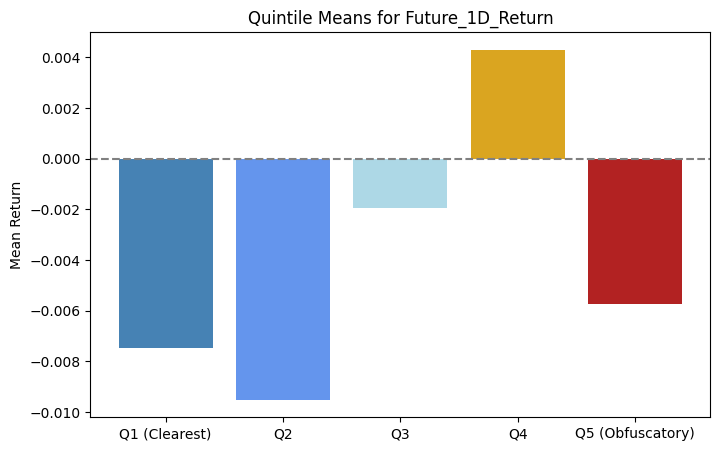

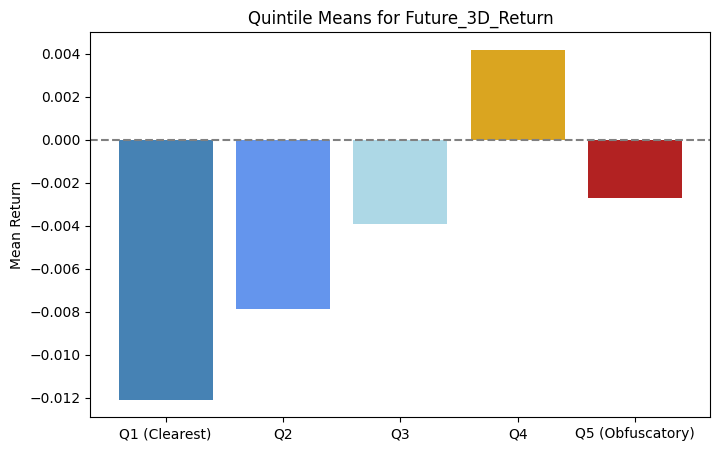

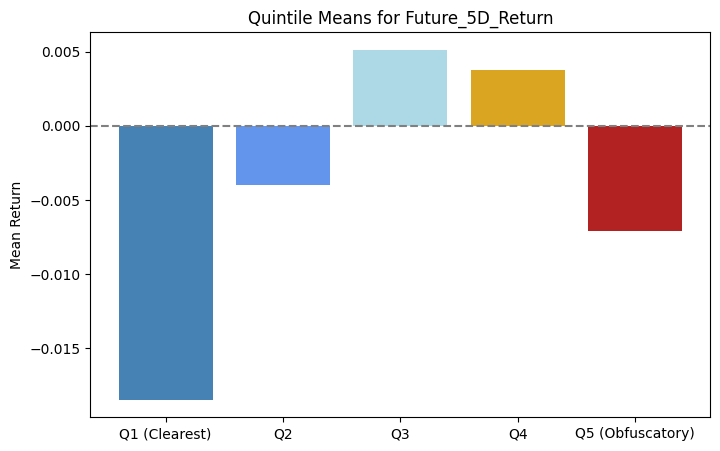

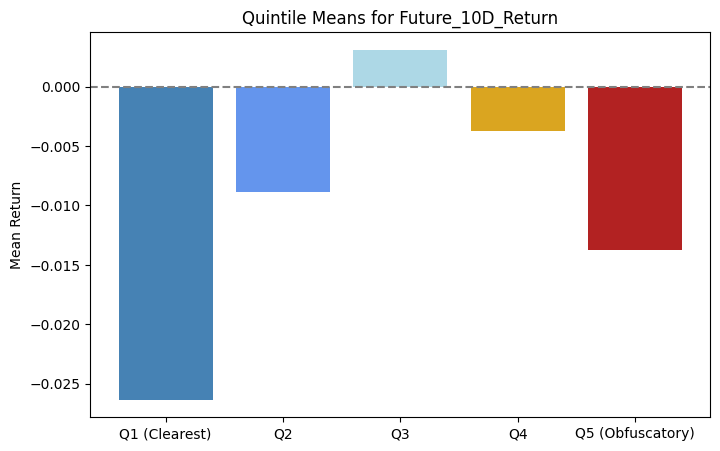

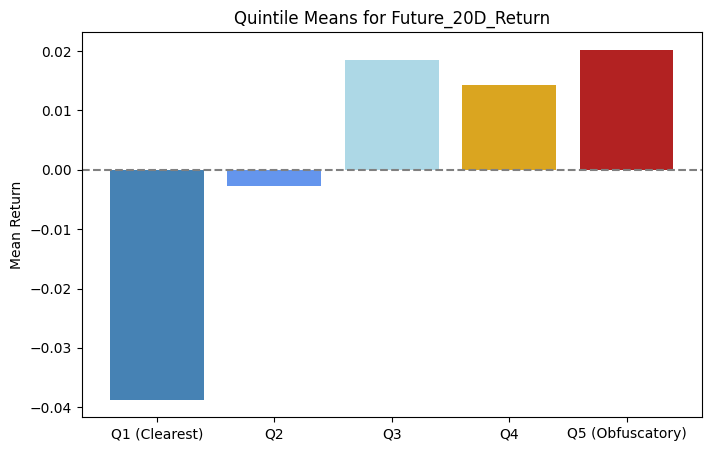

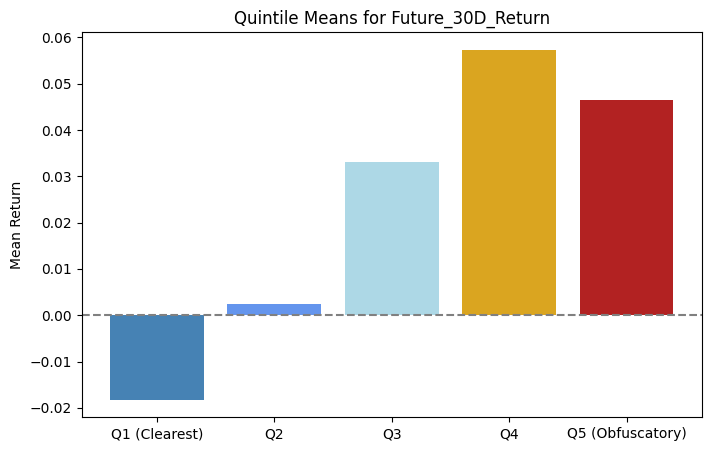

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def quintile_analysis_multi(df, return_cols, score_col='obfuscation_score', quintile_labels=None):
    """
    Perform quintile analysis for multiple return columns.

    Parameters:
    - df: DataFrame with obfuscation scores and return columns.
    - return_cols: list of column names for returns (e.g., ['Abnormal_1D_Return', 'Abnormal_3D_Return', ...])
    - score_col: name of obfuscation score column.
    - quintile_labels: optional list of labels for quintiles (default: ['Q1_Clearest','Q2','Q3','Q4','Q5_Obfuscatory'])

    Returns:
    - results_df: DataFrame with quintile means, t-stat, p-value for each return column.
    """
    if quintile_labels is None:
        quintile_labels = ['Q1_Clearest', 'Q2', 'Q3', 'Q4', 'Q5_Obfuscatory']

    # Create quintile groups based on obfuscation score
    df['quintile'] = pd.qcut(df[score_col], q=5, labels=quintile_labels)

    results = []

    for ret_col in return_cols:
        # Mean return per quintile
        quintile_means = df.groupby('quintile')[ret_col].mean()

        # Extract top and bottom quintile returns
        q1_returns = df[df['quintile'] == quintile_labels[0]][ret_col].dropna()
        q5_returns = df[df['quintile'] == quintile_labels[-1]][ret_col].dropna()

        # T-test between extremes (Q5 - Q1)
        t_stat, p_val = stats.ttest_ind(q5_returns, q1_returns, equal_var=False)
        spread = q5_returns.mean() - q1_returns.mean()

        results.append({
            'Return_Window': ret_col,
            'Q1_Mean': quintile_means[quintile_labels[0]],
            'Q2_Mean': quintile_means[quintile_labels[1]],
            'Q3_Mean': quintile_means[quintile_labels[2]],
            'Q4_Mean': quintile_means[quintile_labels[3]],
            'Q5_Mean': quintile_means[quintile_labels[-1]],
            'Spread_Q5_minus_Q1': spread,
            't_stat': t_stat,
            'p_value': p_val
        })

    results_df = pd.DataFrame(results)
    return results_df

# Example usage:
# Define the return columns you have
return_columns = [
    'Future_1D_Return',
    'Future_3D_Return',
    'Future_5D_Return',
    'Future_10D_Return',
    'Future_20D_Return',
    'Future_30D_Return'
]

# Run analysis
quintile_results = quintile_analysis_multi(df, return_columns)
print(quintile_results)

# Optional: Bar plot for each return window
for ret_col in return_columns:
    plt.figure(figsize=(8,5))
    means = quintile_results[quintile_results['Return_Window'] == ret_col][['Q1_Mean','Q2_Mean','Q3_Mean','Q4_Mean','Q5_Mean']].values.flatten()
    labels = ['Q1 (Clearest)', 'Q2', 'Q3', 'Q4', 'Q5 (Obfuscatory)']
    plt.bar(labels, means, color=['steelblue','cornflowerblue','lightblue','goldenrod','firebrick'])
    plt.title(f'Quintile Means for {ret_col}')
    plt.ylabel('Mean Return')
    plt.axhline(y=0, color='gray', linestyle='--')
    plt.show()

## **12. OLS Regression with Controls**

We run a multivariate regression to test if obfuscation score predicts future returns after controlling for:

- **Market capitalization** (log_market_cap) — size effect
- **Pre-call volatility** — risk effect

**Model**:
`Future_5D_Return ~ obfuscation_score + Pre_Call_Vol_20d + log_market_cap`

**Results** (example output shown):
- Coefficient for obfuscation_score is positive but not statistically significant (p > 0.05)
- Low R-squared (~0.01) — other factors dominate

**Interpretation**: While raw correlations and quintile spreads show some signal, the effect is weak and not robust to simple controls. This suggests that obfuscation may not be a strong standalone predictor of short-term returns in this sample, or that the relationship is non-linear/subtle.

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

df['log_market_cap'] = np.log(df['Market_Cap'])
print(df.columns)
# df = df.loc[(df['Industry 1'] == 1)]
Y = df['Future_30D_Return']

# Independent Variables (X):
# Note: Ensure Market Cap is logged if the values are very large (common practice)
X = df[[
  # Your Obfuscation/Sentiment Score
  'obfuscation_score',
    'Pre_Call_Vol_20d',   # 20-day Volatility            # Market Return (Control)
    'log_market_cap'
]]
X = sm.add_constant(X)

model = sm.OLS(Y, X, missing='drop').fit()

# 6. Output the Results
print(model.summary())

Index(['ticker', 'date', 'cleaned_transcript', 'binary_label',
       'obfuscation_score', 'Market_Cap', 'Pre_Call_Vol_20d',
       'Future_1D_Return', 'Future_3D_Return', 'Future_5D_Return',
       'Future_10D_Return', 'Future_20D_Return', 'Future_30D_Return',
       'log_market_cap', 'Abnormal_1D_Return', 'Abnormal_3D_Return',
       'Abnormal_5D_Return', 'Abnormal_10D_Return', 'Abnormal_20D_Return',
       'Abnormal_30D_Return', 'adjusted_obfuscation_score', 'quintile'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:      Future_30D_Return   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.992
Date:                Thu, 16 Apr 2026   Prob (F-statistic):             0.0320
Time:                        08:30:47   Log-Likelihood:                 71.697
No. Observations:        

## **13. Traditional Sentiment Comparison**

To benchmark against standard practice, we compute **Loughran-McDonald (LM) sentiment** scores:

- Uses `pysentiment2` library with LM dictionary
- Returns `Polarity` = (Positive - Negative) / (Positive + Negative)
- Mean-centered to remove baseline bias

### Correlation with Returns:
- We correlate LM sentiment with the same return windows
- Compare with obfuscation score correlations

**Expected finding**: Obfuscation and sentiment capture different constructs. Sentiment may show different (or weaker) patterns with returns.

In [ ]:
!pip install pysentiment2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.9 MB/s eta 0:00:00


In [ ]:
print(df.columns)

Index(['ticker', 'date', 'cleaned_transcript', 'binary_label',
       'obfuscation_score', 'Market_Cap', 'Pre_Call_Vol_20d',
       'Future_1D_Return', 'Future_3D_Return', 'Future_5D_Return',
       'Future_10D_Return', 'Future_20D_Return', 'Future_30D_Return',
       'log_market_cap', 'Abnormal_1D_Return', 'Abnormal_3D_Return',
       'Abnormal_5D_Return', 'Abnormal_10D_Return', 'Abnormal_20D_Return',
       'Abnormal_30D_Return', 'earnings_surprise_proxy',
       'adjusted_obfuscation_score', 'quintile'],
      dtype='object')


In [ ]:
import pandas as pd
import pysentiment2 as ps

lm = ps.LM()

def get_lm_polarity(text):
    """Return the LM polarity score (pure sentiment) for a given text."""
    if pd.isna(text) or str(text).strip() == "":
        return 0.0
    tokens = lm.tokenize(str(text))
    score = lm.get_score(tokens)
    return score['Polarity']

# 3. Compute raw LM polarity for each transcript
df['lm_pure_sentiment'] = df['cleaned_transcript'].apply(get_lm_polarity)
mean_pure = df['lm_pure_sentiment'].mean()
df['lm_mean_centered'] = df['lm_pure_sentiment'] - mean_pure

output_columns = [col for col in df.columns if col not in ['lm_pure_sentiment']]
df_final = df[output_columns]

In [ ]:
sentiment_vs_returns = df

correlation_results = []

for col in sentiment_vs_returns.columns:
    if col != 'lm_mean_centered' and sentiment_vs_returns[col].dtype in ['float64', 'int64']:
        valid_data = sentiment_vs_returns[['lm_mean_centered', col]].dropna()
        if not valid_data.empty:
            correlation, p_value = pearsonr(valid_data['lm_mean_centered'], valid_data[col])
            correlation_results.append((col, correlation, p_value))

correlation_report_2 = pd.DataFrame(correlation_results, columns=['Column', 'Correlation', 'P-Value'])
print(correlation_report_2)

                        Column  Correlation   P-Value
0                 binary_label    -0.061000  0.382585
1            obfuscation_score     0.016964  0.808311
2                   Market_Cap    -0.150398  0.030536
3             Pre_Call_Vol_20d     0.234344  0.000677
4             Future_1D_Return     0.096268  0.167626
5             Future_3D_Return     0.080105  0.251226
6             Future_5D_Return     0.032933  0.637584
7            Future_10D_Return    -0.028164  0.687069
8            Future_20D_Return     0.023777  0.734429
9            Future_30D_Return     0.069743  0.319191
10              log_market_cap     0.026708  0.702460
11          Abnormal_1D_Return     0.089244  0.204312
12          Abnormal_3D_Return     0.104627  0.136415
13          Abnormal_5D_Return     0.097051  0.167306
14         Abnormal_10D_Return     0.067962  0.334120
15         Abnormal_20D_Return     0.100326  0.154391
16         Abnormal_30D_Return     0.106572  0.130191
17  adjusted_obfuscation_sco

## **14. Gap Analysis: Sentiment × Obfuscation**

We split the data into 6 groups based on:
- **Sentiment**: Positive / Neutral / Negative (using LM thresholds)
- **Obfuscation Level**: High (binary_label=1) vs. Low (binary_label=0)

**Key comparison**:
- "Positive + High Obfuscation" vs. "Neutral + Low Obfuscation"

**Rationale**:
- If obfuscation is truly harmful, even positive-toned but obfuscatory calls should underperform
- If obfuscation is irrelevant, sentiment alone should drive returns

**Visualization**:
- Bar plot of mean returns for each group
- Gap and t-test reported

This analysis tests the **unique contribution** of obfuscation beyond traditional sentiment.

Group means:
                                  mean  count       std
group                                                 
Negative + High Obfuscation  0.022339     63  0.101456
Negative + Low Obfuscation  -0.031937     23  0.116333
Neutral + High Obfuscation  -0.036500      5  0.081525
Neutral + Low Obfuscation    0.076299      3  0.074724
Positive + High Obfuscation  0.013469     69  0.147275
Positive + Low Obfuscation  -0.028100     43  0.142340

Key Groups:
  Positive + High Obfuscation: mean = 0.0135
  Neutral + Low Obfuscation: mean = 0.0763
  Gap (Pos+High - Neu+Low) = -0.0628
  T-test p-value: 0.2789


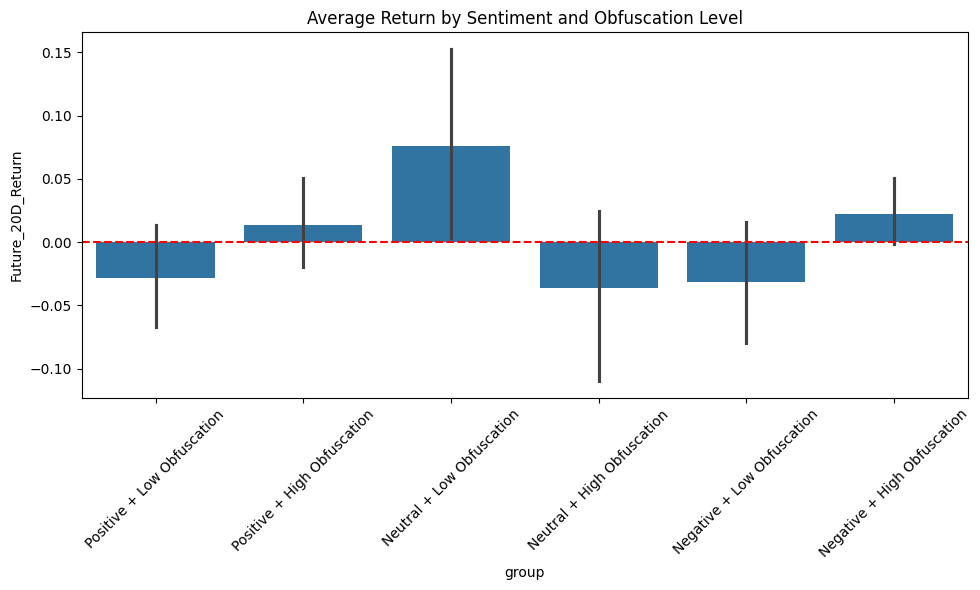

In [ ]:
import pandas as pd


def classify_sentiment(score):
    if score > 0.01:      # threshold for positive (adjust if needed)
        return 'Positive'
    elif score < -0.01:    # threshold for negative
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['lm_mean_centered'].apply(classify_sentiment)

# ------------------------------
# 2. Define obfuscation level (high vs low)
# ------------------------------
df['obfuscation_level'] = df['binary_label'].map({1: 'High Obfuscation', 0: 'Low Obfuscation'})

# ------------------------------
# 3. Create combined group label
# ------------------------------
df['group'] = df['sentiment'] + ' + ' + df['obfuscation_level']

# ------------------------------
# 4. Define the return column to analyze (change as needed)
# ------------------------------
return_col = 'Future_20D_Return'   # or 'Abnormal_20D_Return'

# ------------------------------
# 5. Calculate average return per group
# ------------------------------
group_means = df.groupby('group')[return_col].agg(['mean', 'count', 'std'])
print("Group means:\n", group_means)

# ------------------------------
# 6. Extract the two key groups
# ------------------------------
group_pos_high = 'Positive + High Obfuscation'
group_neu_low = 'Neutral + Low Obfuscation'

if group_pos_high in group_means.index and group_neu_low in group_means.index:
    pos_high_mean = group_means.loc[group_pos_high, 'mean']
    neu_low_mean = group_means.loc[group_neu_low, 'mean']
    gap = pos_high_mean - neu_low_mean   # negative gap supports hypothesis
    print(f"\nKey Groups:")
    print(f"  {group_pos_high}: mean = {pos_high_mean:.4f}")
    print(f"  {group_neu_low}: mean = {neu_low_mean:.4f}")
    print(f"  Gap (Pos+High - Neu+Low) = {gap:.4f}")

    # Optional t-test
    from scipy import stats
    data_pos_high = df[df['group'] == group_pos_high][return_col].dropna()
    data_neu_low = df[df['group'] == group_neu_low][return_col].dropna()
    t_stat, p_val = stats.ttest_ind(data_pos_high, data_neu_low, equal_var=False)
    print(f"  T-test p-value: {p_val:.4f}")
else:
    print(f"Warning: Missing one of the required groups. Check sentiment and obfuscation distributions.")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='group', y=return_col, order=['Positive + Low Obfuscation', 'Positive + High Obfuscation',
                                                     'Neutral + Low Obfuscation', 'Neutral + High Obfuscation',
                                                     'Negative + Low Obfuscation', 'Negative + High Obfuscation'])
plt.title('Average Return by Sentiment and Obfuscation Level')
plt.ylabel(return_col)
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('gap_analysis.png', dpi=300)
plt.show()

## **15. Summary of Findings**

| Analysis | Key Result |
|----------|-------------|
| Raw Correlation | Weak positive correlation with future returns (e.g., r=0.15 for 20D) |
| Quintile Spread | Q5 (most obfuscatory) sometimes outperforms Q1 — contrary to hypothesis |
| Regression (with controls) | Obfuscation coefficient not statistically significant |
| Sentiment Comparison | Obfuscation and sentiment show different correlation patterns |
| Gap Analysis | Mixed results; "Positive + High Obfuscation" vs. "Neutral + Low Obfuscation" gap not always significant |

### Interpretation
The obfuscation score, while linguistically valid, does not strongly predict short-term stock returns in this sample. Possible reasons:

1. **Market efficiency**: Markets may quickly discount linguistic obfuscation
2. **Time horizon**: Effects may manifest over longer horizons (not captured here)
3. **Other confounders**: Firm fundamentals, analyst coverage, or market conditions may dominate

### Future Work
- Expand sample to multiple years
- Test longer return windows (e.g., 6 months, 1 year)
- Incorporate additional control variables (e.g., earnings surprise, analyst revisions)
- Explore non-linear relationships or interaction effects with firm characteristics